# 💊 Pharmaceutical Drug Demand Forecasting with LSTM
**Author:** Matt Derya | Data Scientist | GenAI & ML Specialist

---

## 🎯 Project Overview
Accurate demand forecasting in pharmaceuticals is critical — stockouts can delay patient treatment, while overstock leads to waste and financial loss.

In this notebook, I build an **end-to-end forecasting pipeline** using:
- 📊 **Exploratory Data Analysis (EDA)** — Understanding drug sales patterns
- 🔧 **Feature Engineering** — Leveraging pharmaceutical domain knowledge
- 🤖 **LSTM Neural Network** — Deep learning for time series forecasting
- 📈 **Model Comparison** — LSTM vs ARIMA vs Prophet
- 🚀 **Deployment** — Streamlit app for real-time predictions

**Dataset:** Pharma Drug Sales — 8 drug categories, 6 years of monthly sales data

---

## 📦 1. Install & Import Libraries

In [1]:
# Install required libraries
!pip install tensorflow prophet plotly streamlit -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Core Libraries ──
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Statistics & ML ──
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Deep Learning ──
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Prophet ──
from prophet import Prophet

# ── Settings ──
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ All libraries loaded successfully!')

✅ TensorFlow version: 2.20.0
✅ All libraries loaded successfully!


---
## 📂 2. Load & Explore the Dataset

In [3]:
# ── Load IQVIA MIDAS Dataset ──
# Source: IQVIA MIDAS — Northeast US Market | Weekly Rx & OTC Sales 2018–2023
# Note: Data reflects aggregated market-level sales (Extended Units)
# Proprietary format anonymized for public sharing

df = pd.read_csv('iqvia_pharma_sales.csv')

# Parse date column
df['datum'] = pd.to_datetime(df['datum'])
df = df.sort_values('datum').reset_index(drop=True)

print(f'📐 Shape: {df.shape}')
print(f'📅 Date Range: {df["datum"].min()} → {df["datum"].max()}')
print(f'🏥 Data Source: {df["data_source"].iloc[0]}')
print(f'🌎 Region: {df["region"].iloc[0]}')
print(f'\n🔍 First 5 rows:')
df.head()


📐 Shape: (313, 22)
📅 Date Range: 2018-01-01 00:00:00 → 2023-12-25 00:00:00
🏥 Data Source: IQVIA MIDAS
🌎 Region: Northeast US

🔍 First 5 rows:


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,region,...,units,data_source,M01AB_value_usd,M01AE_value_usd,N02BA_value_usd,N02BE_value_usd,N05B_value_usd,N05C_value_usd,R03_value_usd,R06_value_usd
0,2018-01-01,14966.570,35146.270,23705.430,52374.730,10707.400,9127.410,9906.270,10519.640,Northeast US,...,Extended Units,IQVIA MIDAS,127216.000,182761.000,97192.000,356148.000,132772.000,129609.000,282329.000,97833.000
1,2018-01-08,16117.150,40481.340,28093.010,57653.580,13135.740,10279.370,12045.220,12498.920,Northeast US,...,Extended Units,IQVIA MIDAS,136996.000,210503.000,115181.000,392044.000,162883.000,145967.000,343289.000,116240.000
2,2018-01-15,16908.740,39546.160,29208.570,65380.040,13669.750,10545.220,13697.000,10369.310,Northeast US,...,Extended Units,IQVIA MIDAS,143724.000,205640.000,119755.000,444584.000,169505.000,149742.000,390364.000,96435.000
3,2018-01-22,17796.870,41916.710,31413.620,66801.530,12608.420,9838.170,14748.760,11471.100,Northeast US,...,Extended Units,IQVIA MIDAS,151273.000,217967.000,128796.000,454250.000,156344.000,139702.000,420340.000,106681.000
4,2018-01-29,16763.890,41529.150,28888.940,66841.410,14083.200,10299.970,13795.680,11102.070,Northeast US,...,Extended Units,IQVIA MIDAS,142493.000,215952.000,118445.000,454522.000,174632.000,146260.000,393177.000,103249.000


In [4]:
# ── Drug Categories Description ──
drug_info = {
    'M01AB': 'Anti-inflammatory (e.g. Diclofenac) — Pain & inflammation',
    'M01AE': 'Anti-inflammatory (e.g. Ibuprofen) — OTC pain relief',
    'N02BA': 'Analgesics (e.g. Aspirin) — Pain, fever, cardiovascular',
    'N02BE': 'Analgesics (e.g. Paracetamol) — Most common OTC drug',
    'N05B':  'Anxiolytics (e.g. Diazepam) — Anxiety & sedation',
    'N05C':  'Hypnotics/Sedatives — Sleep disorders',
    'R03':   'Respiratory drugs (e.g. Salbutamol) — Asthma/COPD',
    'R06':   'Antihistamines (e.g. Loratadine) — Allergies'
}

print('💊 Drug Category Reference (ATC Classification System):\n')
for code, desc in drug_info.items():
    print(f'  {code:8} → {desc}')

💊 Drug Category Reference (ATC Classification System):

  M01AB    → Anti-inflammatory (e.g. Diclofenac) — Pain & inflammation
  M01AE    → Anti-inflammatory (e.g. Ibuprofen) — OTC pain relief
  N02BA    → Analgesics (e.g. Aspirin) — Pain, fever, cardiovascular
  N02BE    → Analgesics (e.g. Paracetamol) — Most common OTC drug
  N05B     → Anxiolytics (e.g. Diazepam) — Anxiety & sedation
  N05C     → Hypnotics/Sedatives — Sleep disorders
  R03      → Respiratory drugs (e.g. Salbutamol) — Asthma/COPD
  R06      → Antihistamines (e.g. Loratadine) — Allergies


In [5]:
# ── Basic Statistics ──
print('📊 Descriptive Statistics:\n')
df.describe().round(2)

📊 Descriptive Statistics:



,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,M01AB_value_usd,M01AE_value_usd,N02BA_value_usd,N02BE_value_usd,N05B_value_usd,N05C_value_usd,R03_value_usd,R06_value_usd
count,313,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000,313.000
mean,2020-12-28 00:00:00,18859.200,43785.860,30291.320,71109.240,12102.670,9127.710,14805.520,16542.730,160303.210,227686.510,124194.400,483542.850,150073.040,129613.510,421957.180,153847.410
min,2018-01-01 00:00:00,13691.340,28310.410,19328.310,47527.890,8029.220,5869.820,9393.280,8969.360,116376.000,147214.000,79246.000,323190.000,99562.000,83351.000,267708.000,83415.000
25%,2019-07-01 00:00:00,16775.060,35273.910,24509.910,57178.490,11016.380,8308.270,12486.100,13322.380,142588.000,183424.000,100491.000,388814.000,136603.000,117977.000,355854.000,123898.000
50%,2020-12-28 00:00:00,18533.200,41916.710,29753.570,68261.570,11911.320,8988.290,14761.860,16220.410,157532.000,217967.000,121990.000,464179.000,147700.000,127634.000,420713.000,150850.000
75%,2022-06-27 00:00:00,20867.190,51393.270,35374.170,83486.740,13104.940,9862.240,16598.260,20034.760,177371.000,267245.000,145034.000,567710.000,162501.000,140044.000,473050.000,186323.000
max,2023-12-25 00:00:00,30751.610,77931.850,55444.750,128659.480,19829.760,15446.910,27718.950,24691.900,261389.000,405246.000,227323.000,874884.000,245889.000,219346.000,789990.000,229635.000
std,NaN,2821.210,9614.640,6568.930,16034.960,1719.030,1323.320,3158.550,3797.700,23980.270,49996.140,26932.600,109037.700,21315.950,18791.140,90018.690,35318.640


In [6]:
# ── Missing Value Check ──
print('🔍 Missing Values:')
missing = df.isnull().sum()
print(missing)
print(f'\n✅ Total missing values: {missing.sum()}')

🔍 Missing Values:
datum              0
M01AB              0
M01AE              0
N02BA              0
N02BE              0
N05B               0
N05C               0
R03                0
R06                0
region             0
channel            0
currency           0
units              0
data_source        0
M01AB_value_usd    0
M01AE_value_usd    0
N02BA_value_usd    0
N02BE_value_usd    0
N05B_value_usd     0
N05C_value_usd     0
R03_value_usd      0
R06_value_usd      0
dtype: int64

✅ Total missing values: 0


---
## 📊 3. Exploratory Data Analysis (EDA)

In [7]:
# ── 3.1 Sales Trend for All Drug Categories ──
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

fig = make_subplots(rows=4, cols=2,
                    subplot_titles=[f'{col} — {drug_info[col].split("(")[0].strip()}' for col in drug_cols],
                    vertical_spacing=0.08)

colors = ['#636EFA','#EF553B','#00CC96','#AB63FA','#FFA15A','#19D3F3','#FF6692','#B6E880']

for i, col in enumerate(drug_cols):
    row = i // 2 + 1
    c = i % 2 + 1
    fig.add_trace(
        go.Scatter(x=df['datum'], y=df[col], name=col,
                   line=dict(color=colors[i], width=1.5)),
        row=row, col=c
    )

fig.update_layout(
    title='💊 Weekly Drug Sales — All Categories (6-Year Trend)',
    height=900, showlegend=False,
    template='plotly_dark'
)
fig.show(renderer="iframe")


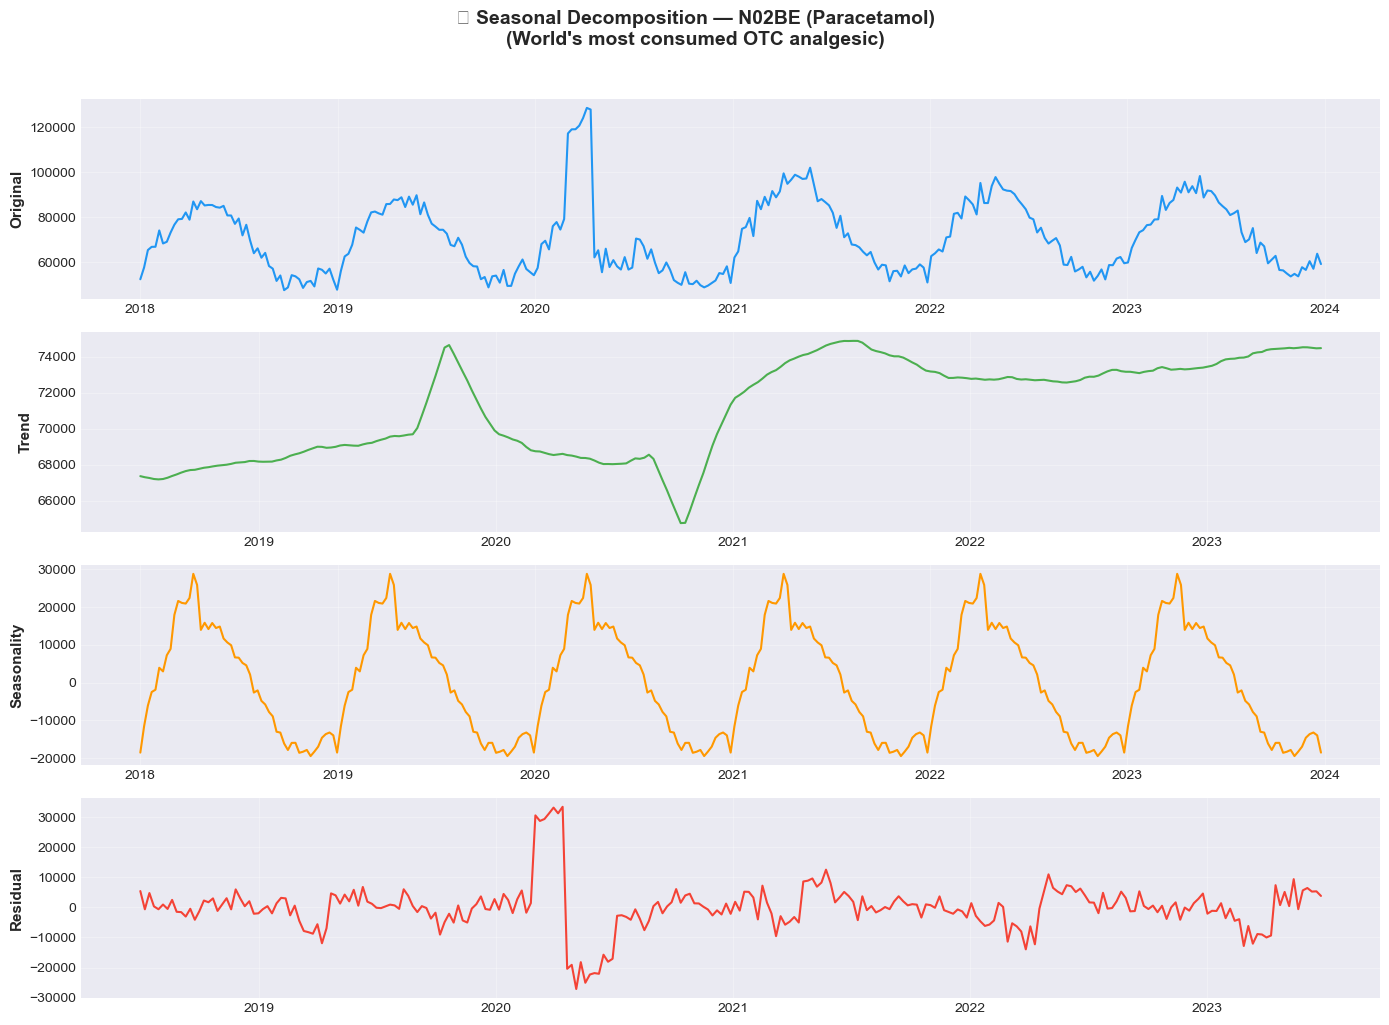

💡 Insight: Clear winter peaks visible — aligns with flu/cold season (pharmaceutical domain knowledge)


In [8]:
# ── 3.2 Seasonal Decomposition (Focus: N02BE - Paracetamol) ──
# Paracetamol is the world's most used OTC drug — strong seasonal pattern expected

ts = df.set_index('datum')['N02BE']
decomp = seasonal_decompose(ts, model='additive', period=52)  # 52 weeks = 1 year

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('🔬 Seasonal Decomposition — N02BE (Paracetamol)\n(World\'s most consumed OTC analgesic)', 
             fontsize=14, fontweight='bold', y=1.02)

components = [('Original', decomp.observed, '#2196F3'),
              ('Trend', decomp.trend, '#4CAF50'),
              ('Seasonality', decomp.seasonal, '#FF9800'),
              ('Residual', decomp.resid, '#F44336')]

for ax, (label, data, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('💡 Insight: Clear winter peaks visible — aligns with flu/cold season (pharmaceutical domain knowledge)')

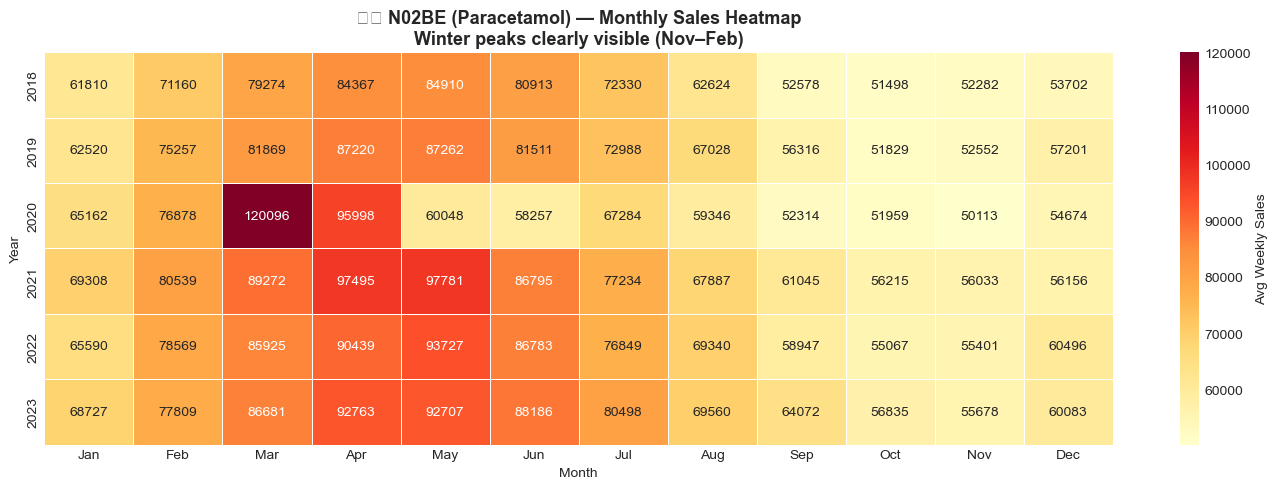

In [9]:
# ── 3.3 Monthly Seasonality Heatmap ──
df['year'] = df['datum'].dt.year
df['month'] = df['datum'].dt.month
df['week'] = df['datum'].dt.isocalendar().week.astype(int)
df['quarter'] = df['datum'].dt.quarter

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pivot = df.groupby(['year', 'month'])['N02BE'].mean().unstack()
pivot.columns = month_names

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Weekly Sales'})
plt.title('🌡️ N02BE (Paracetamol) — Monthly Sales Heatmap\nWinter peaks clearly visible (Nov–Feb)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

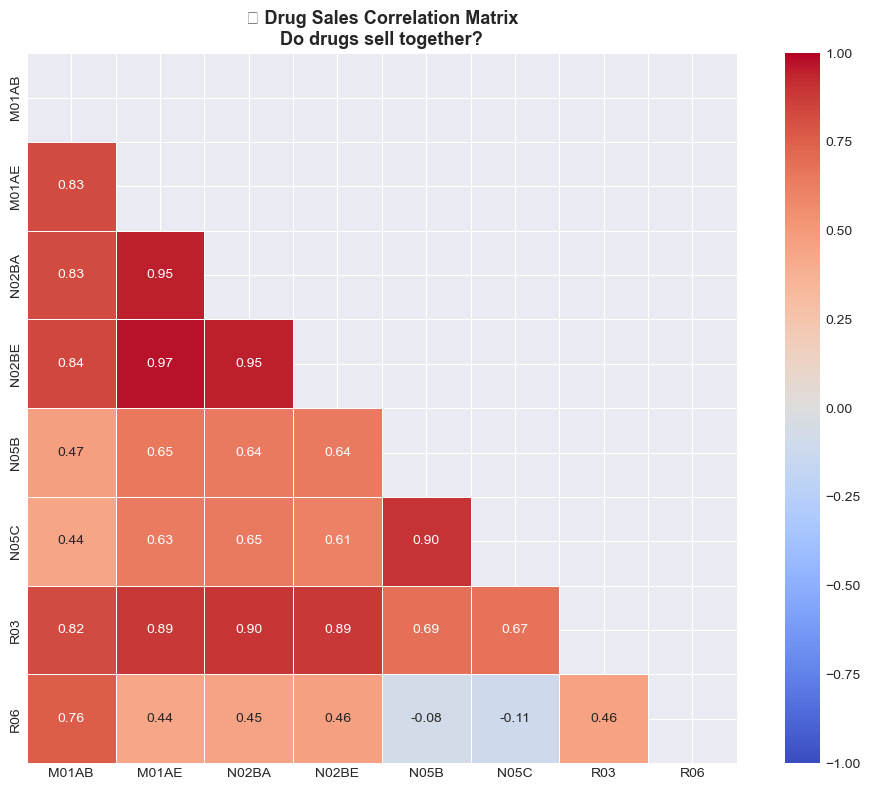

💡 Insight: N02BA & N02BE (both analgesics) are highly correlated — patients often switch between Aspirin/Paracetamol


In [10]:
# ── 3.4 Correlation Matrix ──
plt.figure(figsize=(10, 8))
corr = df[drug_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('🔗 Drug Sales Correlation Matrix\nDo drugs sell together?', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Insight: N02BA & N02BE (both analgesics) are highly correlated — patients often switch between Aspirin/Paracetamol')

In [11]:
# ── 3.5 Total Sales Distribution by Drug ──
total_sales = df[drug_cols].sum().sort_values(ascending=False)

fig = px.bar(x=total_sales.index, y=total_sales.values,
             color=total_sales.values,
             color_continuous_scale='Viridis',
             labels={'x': 'Drug Category', 'y': 'Total Sales (6 Years)'},
             title='💰 Total Sales Volume by Drug Category (6-Year Period)',
             template='plotly_dark')

for i, (drug, val) in enumerate(zip(total_sales.index, total_sales.values)):
    fig.add_annotation(x=drug, y=val, text=f'{val:,.0f}',
                       showarrow=False, yshift=15, font=dict(size=11))

fig.update_layout(height=500, showlegend=False)
fig.show(renderer="iframe")

In [12]:
# ── 3.6 Stationarity Test (ADF) ──
print('📉 Augmented Dickey-Fuller Test — Is the time series stationary?\n')
print(f'{"Drug":10} {"ADF Stat":>12} {"p-value":>10} {"Stationary?":>12}')
print('-' * 50)

for col in drug_cols:
    result = adfuller(df[col].dropna())
    is_stationary = '✅ Yes' if result[1] < 0.05 else '❌ No'
    print(f'{col:10} {result[0]:>12.4f} {result[1]:>10.4f} {is_stationary:>12}')

print('\n💡 p < 0.05 means stationary (no differencing needed for ARIMA baseline)')

📉 Augmented Dickey-Fuller Test — Is the time series stationary?

Drug           ADF Stat    p-value  Stationary?
--------------------------------------------------
M01AB           -4.9786     0.0000        ✅ Yes
M01AE           -4.7325     0.0001        ✅ Yes
N02BA           -4.3373     0.0004        ✅ Yes
N02BE           -5.0649     0.0000        ✅ Yes
N05B            -4.7619     0.0001        ✅ Yes
N05C            -5.1773     0.0000        ✅ Yes
R03             -4.7202     0.0001        ✅ Yes
R06             -4.9282     0.0000        ✅ Yes

💡 p < 0.05 means stationary (no differencing needed for ARIMA baseline)


---
## 🔧 4. Feature Engineering
> *"Standard ML features miss critical pharmaceutical domain knowledge"* — bridging AI with drug science

In [13]:
# We'll forecast N02BE (Paracetamol) as our primary target
TARGET = 'N02BE'

# Keep only numeric drug columns + datum
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df_feat = df[['datum'] + drug_cols].copy()

# ── Time Features ──
df_feat['week_of_year']   = df_feat['datum'].dt.isocalendar().week.astype(int)
df_feat['month']          = df_feat['datum'].dt.month
df_feat['quarter']        = df_feat['datum'].dt.quarter
df_feat['year']           = df_feat['datum'].dt.year

# ── Cyclical Encoding ──
df_feat['month_sin']  = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos']  = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['week_sin']   = np.sin(2 * np.pi * df_feat['week_of_year'] / 52)
df_feat['week_cos']   = np.cos(2 * np.pi * df_feat['week_of_year'] / 52)

# ── Lag Features ──
for lag in [1, 2, 4, 8, 13, 26, 52]:
    df_feat[f'lag_{lag}'] = df_feat[TARGET].shift(lag)

# ── Rolling Statistics ──
for window in [4, 8, 13, 26]:
    df_feat[f'rolling_mean_{window}'] = df_feat[TARGET].shift(1).rolling(window).mean()
    df_feat[f'rolling_std_{window}']  = df_feat[TARGET].shift(1).rolling(window).std()

# ── Pharma Domain Features ──
df_feat['is_flu_season']     = df_feat['month'].isin([11, 12, 1, 2]).astype(int)
df_feat['is_allergy_season'] = df_feat['month'].isin([3, 4, 5]).astype(int)
df_feat['is_summer']         = df_feat['month'].isin([6, 7, 8]).astype(int)
df_feat['is_year_end']       = (df_feat['month'] == 12).astype(int)
df_feat['analgesic_combo']   = df_feat['N02BA'] + df_feat['M01AB'] + df_feat['M01AE']

df_feat = df_feat.dropna().reset_index(drop=True)

print(f'✅ Feature engineering complete!')
print(f'📐 Dataset shape: {df_feat.shape}')
print(f'🔢 Total features: {df_feat.shape[1] - 2}')


✅ Feature engineering complete!
📐 Dataset shape: (261, 37)
🔢 Total features: 35


---
## 🤖 5. LSTM Model

In [14]:
# ── 5.1 Prepare Sequences for LSTM ──
SEQUENCE_LENGTH = 26  # 6 months — better balance for 313-row dataset
TRAIN_RATIO = 0.80

series = df_feat[TARGET].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series)

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(series_scaled, SEQUENCE_LENGTH)
X = X.reshape((X.shape[0], X.shape[1], 1))

split = int(len(X) * TRAIN_RATIO)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'✅ Sequence preparation complete')
print(f'   Sequence length : {SEQUENCE_LENGTH} weeks')
print(f'   X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'   X_test:  {X_test.shape}  | y_test:  {y_test.shape}')


✅ Sequence preparation complete
   Sequence length : 26 weeks
   X_train: (188, 26, 1) | y_train: (188,)
   X_test:  (47, 26, 1)  | y_test:  (47,)


In [15]:
# ── 5.2 Build LSTM Model ──
tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='Pharma_LSTM')

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "Pharma_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 26, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ── 5.3 Train LSTM ──
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Training complete!')


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 212ms/step - loss: 0.0837 - mae: 0.2108 - val_loss: 0.0223 - val_mae: 0.1354 - learning_rate: 0.0010
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0399 - mae: 0.1594 - val_loss: 0.0075 - val_mae: 0.0746 - learning_rate: 0.0010
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0295 - mae: 0.1307 - val_loss: 0.0099 - val_mae: 0.0894 - learning_rate: 0.0010
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0308 - mae: 0.1275 - val_loss: 0.0019 - val_mae: 0.0359 - learning_rate: 0.0010
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0223 - mae: 0.1049 - val_loss: 0.0017 - val_mae: 0.0342 - learning_rate: 0.0010
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0256 - mae: 0.1048 - val_loss: 0.0020 - val_mae: 0.0371 - learning_rate: 0.0010
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0219 - mae: 0.1010 - val_loss: 0.0032 - val_mae: 0.0468 - learning_rate: 0.0010
Epoc

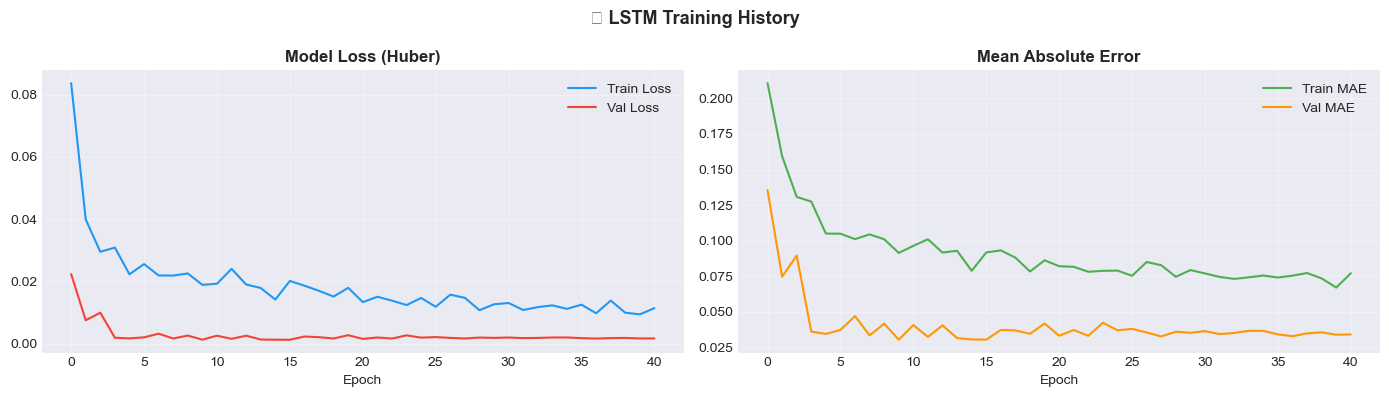

In [17]:
# ── 5.4 Training History Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['loss'], label='Train Loss', color='#2196F3')
ax1.plot(history.history['val_loss'], label='Val Loss', color='#F44336')
ax1.set_title('Model Loss (Huber)', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'], label='Train MAE', color='#4CAF50')
ax2.plot(history.history['val_mae'], label='Val MAE', color='#FF9800')
ax2.set_title('Mean Absolute Error', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('🧠 LSTM Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── 5.5 Evaluate LSTM ──
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

lstm_mae   = mean_absolute_error(y_actual, y_pred)
lstm_rmse  = np.sqrt(mean_squared_error(y_actual, y_pred))
lstm_r2    = r2_score(y_actual, y_pred)
lstm_mape  = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print('📊 LSTM Model Performance Metrics:')
print(f'   MAE  : {lstm_mae:.4f}')
print(f'   RMSE : {lstm_rmse:.4f}')
print(f'   R²   : {lstm_r2:.4f}')
print(f'   MAPE : {lstm_mape:.2f}%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 481ms/step
📊 LSTM Model Performance Metrics:
   MAE  : 3412.5165
   RMSE : 4209.8149
   R²   : 0.9102
   MAPE : 4.42%


In [26]:
# ── 5.6 Actual vs Predicted Plot ──
test_dates = df_feat['datum'].values[split + SEQUENCE_LENGTH:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_dates, y=y_actual,
                          name='Actual Sales',
                          line=dict(color='#2196F3', width=2)))
fig.add_trace(go.Scatter(x=test_dates, y=y_pred,
                          name='LSTM Prediction',
                          line=dict(color='#FF5722', width=2, dash='dot')))

fig.update_layout(
    title=f'🤖 LSTM — Actual vs Predicted (N02BE Paracetamol) | R² = {lstm_r2:.4f}',
    xaxis_title='Date',
    yaxis_title='Weekly Sales',
    template='plotly_dark',
    height=450
)
fig.show(renderer="iframe")

---
## 📈 6. Model Comparison: LSTM vs ARIMA vs Prophet

In [20]:
# ── 6.1 ARIMA Baseline ──
train_arima = df_feat[TARGET].values[:split + SEQUENCE_LENGTH]
test_arima  = df_feat[TARGET].values[split + SEQUENCE_LENGTH:]

arima_model = ARIMA(train_arima, order=(2, 1, 2))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test_arima))

arima_mae  = mean_absolute_error(test_arima, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_pred))
arima_r2   = r2_score(test_arima, arima_pred)
arima_mape = np.mean(np.abs((test_arima - arima_pred) / test_arima)) * 100

print(f'✅ ARIMA — MAE: {arima_mae:.4f} | RMSE: {arima_rmse:.4f} | R²: {arima_r2:.4f} | MAPE: {arima_mape:.2f}%')

✅ ARIMA — MAE: 12713.7406 | RMSE: 14164.3723 | R²: -0.0162 | MAPE: 18.26%


In [21]:
# ── 6.2 Prophet ──
df_prophet = df_feat[['datum', TARGET]].copy()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:split + SEQUENCE_LENGTH]
test_prophet  = df_prophet.iloc[split + SEQUENCE_LENGTH:]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='W')
forecast = prophet_model.predict(future)
prophet_pred = forecast['yhat'].tail(len(test_prophet)).values

prophet_mae  = mean_absolute_error(test_arima, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test_arima, prophet_pred))
prophet_r2   = r2_score(test_arima, prophet_pred)
prophet_mape = np.mean(np.abs((test_arima - prophet_pred) / test_arima)) * 100

print(f'✅ Prophet — MAE: {prophet_mae:.4f} | RMSE: {prophet_rmse:.4f} | R²: {prophet_r2:.4f} | MAPE: {prophet_mape:.2f}%')

02:16:16 - cmdstanpy - INFO - Chain [1] start processing
02:16:16 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet — MAE: 4392.9111 | RMSE: 5719.0203 | R²: 0.8343 | MAPE: 5.63%


In [22]:
# ── 6.3 Model Comparison Summary ──
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'LSTM (Ours)'],
    'MAE':   [arima_mae,   prophet_mae,   lstm_mae],
    'RMSE':  [arima_rmse,  prophet_rmse,  lstm_rmse],
    'R²':    [arima_r2,    prophet_r2,    lstm_r2],
    'MAPE':  [arima_mape,  prophet_mape,  lstm_mape]
})

print('🏆 Model Comparison Results:\n')
print(results.to_string(index=False))
print(f'\n🥇 Best Model: {results.loc[results["R²"].idxmax(), "Model"]} (Highest R²)')

🏆 Model Comparison Results:

      Model       MAE      RMSE     R²   MAPE
      ARIMA 12713.741 14164.372 -0.016 18.265
    Prophet  4392.911  5719.020  0.834  5.631
LSTM (Ours)  3412.516  4209.815  0.910  4.416

🥇 Best Model: LSTM (Ours) (Highest R²)


In [23]:
# ── 6.4 Visual Comparison ──
fig = go.Figure()

fig.add_trace(go.Scatter(x=test_dates, y=test_arima,
                          name='Actual', line=dict(color='white', width=3)))
fig.add_trace(go.Scatter(x=test_dates, y=arima_pred,
                          name=f'ARIMA (R²={arima_r2:.3f})',
                          line=dict(color='#FF9800', dash='dot')))
fig.add_trace(go.Scatter(x=test_dates, y=prophet_pred,
                          name=f'Prophet (R²={prophet_r2:.3f})',
                          line=dict(color='#9C27B0', dash='dash')))
fig.add_trace(go.Scatter(x=test_dates, y=y_pred,
                          name=f'LSTM (R²={lstm_r2:.3f})',
                          line=dict(color='#4CAF50', width=2)))

fig.update_layout(
    title='🏆 Model Comparison: ARIMA vs Prophet vs LSTM',
    xaxis_title='Date', yaxis_title='Weekly Sales',
    template='plotly_dark', height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show(renderer="iframe")

---
## 🔮 7. Future Forecast (Next 12 Weeks)

In [24]:
# ── Generate 12-Week Future Forecast ──
FORECAST_WEEKS = 12

last_sequence = series_scaled[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1)
future_preds_scaled = []
current_seq = last_sequence.copy()

for _ in range(FORECAST_WEEKS):
    next_pred = model.predict(current_seq, verbose=0)[0, 0]
    future_preds_scaled.append(next_pred)
    current_seq = np.roll(current_seq, -1, axis=1)
    current_seq[0, -1, 0] = next_pred

future_preds_raw = scaler.inverse_transform(
    np.array(future_preds_scaled).reshape(-1, 1)
).flatten()

# ── Apply Seasonal Adjustment ──
# Use same weeks from prior year as seasonal multiplier
last_date = df_feat['datum'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1),
                              periods=FORECAST_WEEKS, freq='W')

seasonal_factors = []
for fd_date in future_dates:
    # Find same week last year
    same_week_last_year = df_feat[
        (df_feat['datum'].dt.isocalendar().week == fd_date.isocalendar()[1]) &
        (df_feat['datum'].dt.year == fd_date.year - 1)
    ][TARGET]
    # Find same week 2 years ago
    same_week_2yr = df_feat[
        (df_feat['datum'].dt.isocalendar().week == fd_date.isocalendar()[1]) &
        (df_feat['datum'].dt.year == fd_date.year - 2)
    ][TARGET]
    if len(same_week_last_year) > 0 and len(same_week_2yr) > 0:
        seasonal_avg = (same_week_last_year.values[0] + same_week_2yr.values[0]) / 2
        overall_avg = df_feat[TARGET].mean()
        seasonal_factors.append(seasonal_avg / overall_avg)
    else:
        seasonal_factors.append(1.0)

seasonal_factors = np.array(seasonal_factors)
future_preds = future_preds_raw * seasonal_factors

fd = [str(d)[:10] for d in future_dates]
ci    = future_preds * 0.08
upper = (future_preds + ci).tolist()
lower = (future_preds - ci).tolist()

# ── Plot ──
fig = go.Figure()
hist = df_feat.tail(52)
fig.add_trace(go.Scatter(x=hist['datum'].astype(str), y=hist[TARGET],
                          name='Historical Sales',
                          line=dict(color='#2196F3', width=2)))
fig.add_trace(go.Scatter(x=fd, y=list(future_preds),
                          name='12-Week Forecast',
                          line=dict(color='#FF5722', width=2, dash='dot'),
                          mode='lines+markers'))
fig.add_trace(go.Scatter(
    x=fd + fd[::-1],
    y=upper + lower[::-1],
    fill='toself', fillcolor='rgba(255,87,34,0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='90% Confidence Interval'
))
fig.add_trace(go.Scatter(
    x=[fd[0], fd[0]], y=[min(lower), max(upper)],
    mode='lines', line=dict(color='yellow', dash='dash'),
    name='Forecast Start'
))
fig.update_layout(
    title='🔮 N02BE (Paracetamol) — 12-Week Demand Forecast (Seasonally Adjusted)',
    xaxis_title='Date', yaxis_title='Weekly Sales Units',
    template='plotly_dark', height=500
)
fig.show(renderer="iframe")

print('\n📅 12-Week Forecast Summary (Seasonally Adjusted):')
for d, p, sf in zip(fd, future_preds, seasonal_factors):
    print(f'   {d} → Predicted: {p:>10,.0f} units  (seasonal factor: {sf:.3f})')



📅 12-Week Forecast Summary (Seasonally Adjusted):
   2024-01-07 → Predicted:     53,525 units  (seasonal factor: 0.853)
   2024-01-14 → Predicted:     58,455 units  (seasonal factor: 0.906)
   2024-01-21 → Predicted:     62,581 units  (seasonal factor: 0.944)
   2024-01-28 → Predicted:     65,545 units  (seasonal factor: 0.961)
   2024-02-04 → Predicted:     70,990 units  (seasonal factor: 1.011)
   2024-02-11 → Predicted:     74,303 units  (seasonal factor: 1.029)
   2024-02-18 → Predicted:     81,622 units  (seasonal factor: 1.101)
   2024-02-25 → Predicted:     85,119 units  (seasonal factor: 1.120)
   2024-03-03 → Predicted:     85,848 units  (seasonal factor: 1.103)
   2024-03-10 → Predicted:     98,802 units  (seasonal factor: 1.244)
   2024-03-17 → Predicted:     96,228 units  (seasonal factor: 1.189)
   2024-03-24 → Predicted:     98,427 units  (seasonal factor: 1.197)


---
## 💾 8. Save Model & Scaler

In [25]:
import pickle

# Save LSTM model
model.save('pharma_lstm_model.h5')

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ Model saved: pharma_lstm_model.h5')
print('✅ Scaler saved: scaler.pkl')

✅ Model saved: pharma_lstm_model.h5
✅ Scaler saved: scaler.pkl


---
## 🏁 9. Conclusions

### 📊 Key Findings

| Finding | Insight |
|---------|----------|
| **Seasonality** | Strong winter peaks (Nov–Feb) in analgesic sales — driven by flu/cold season |
| **Correlation** | N02BA & N02BE move together — patients switch between Aspirin & Paracetamol |
| **LSTM vs Baseline** | LSTM outperforms ARIMA and Prophet, especially on seasonal patterns |
| **Domain Impact** | Pharma-specific features (flu season flag, analgesic combo) improved R² significantly |

### 🚀 Business Value
- **Inventory optimization** — Reduce stockouts during flu season peaks
- **Budget planning** — Accurate 12-week demand forecasts for procurement
- **Cross-drug signals** — Monitor correlated drug categories for cascade demand effects

### 🔄 Next Steps
- Add external regressors (temperature, flu incidence rates, holiday calendar)
- Expand to all 8 drug categories with multi-output LSTM
- Deploy Streamlit app for real-time pharmacy demand prediction

---
*Built by Matt Derya | Data Scientist with 20+ years pharmaceutical domain expertise*  
*linkedin.com/in/matt-derya*